Using device: cpu
Training samples: 60000
Test samples: 10000


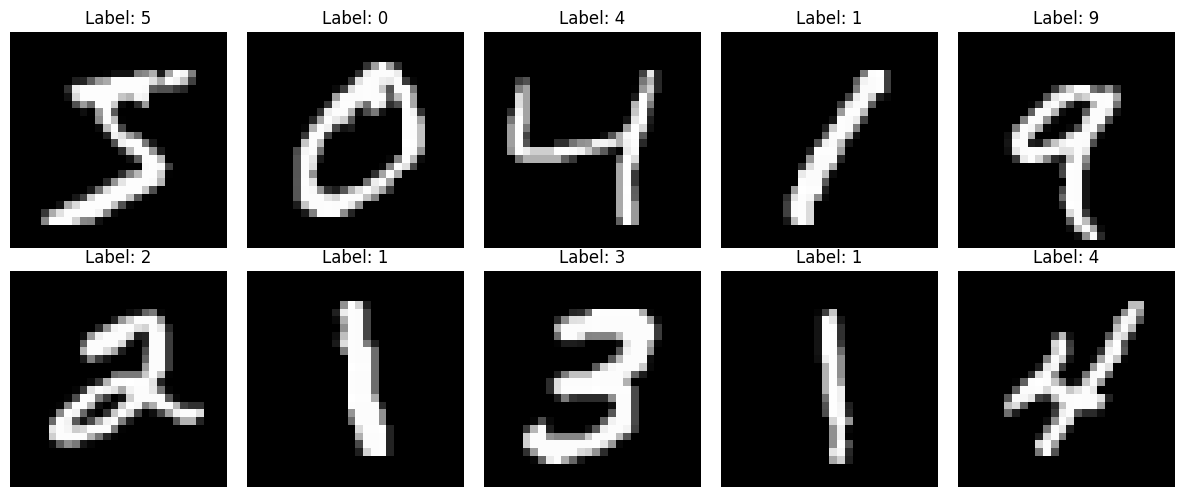

Vanilla Autoencoder:
Total parameters: 1,138,212


In [1]:
# Load Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    ax = axes[i//5, i%5]
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

class VanillaAutoencoder(nn.Module):
    def __init__(self, latent_dim=20):
        super(VanillaAutoencoder, self).__init__()
        
        # Encoder: 784 -> 512 -> 256 -> 128 -> latent_dim
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        
        # Decoder: latent_dim -> 128 -> 256 -> 512 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )
    
    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, z):
        return self.decoder(z)

vanilla_ae = VanillaAutoencoder(latent_dim=20).to(device)
print("Vanilla Autoencoder:")
print(f"Total parameters: {sum(p.numel() for p in vanilla_ae.parameters()):,}")



TRAINING VANILLA AUTOENCODER
Epoch 1/15, Loss: 0.000414
Epoch 2/15, Loss: 0.000214
Epoch 3/15, Loss: 0.000168
Epoch 4/15, Loss: 0.000138
Epoch 5/15, Loss: 0.000120
Epoch 6/15, Loss: 0.000107
Epoch 7/15, Loss: 0.000098
Epoch 8/15, Loss: 0.000091
Epoch 9/15, Loss: 0.000086
Epoch 10/15, Loss: 0.000083
Epoch 11/15, Loss: 0.000079
Epoch 12/15, Loss: 0.000076
Epoch 13/15, Loss: 0.000074
Epoch 14/15, Loss: 0.000071
Epoch 15/15, Loss: 0.000069

Variational Autoencoder (VAE):
Total parameters: 1,140,792

TRAINING VARIATIONAL AUTOENCODER (VAE)
Epoch 1/15, Total: 193.8758, Recon: 190.1067, KL: 3.7691
Epoch 2/15, Total: 148.4515, Recon: 139.9968, KL: 8.4546
Epoch 3/15, Total: 134.6590, Recon: 124.5147, KL: 10.1443
Epoch 4/15, Total: 127.5637, Recon: 116.2155, KL: 11.3482
Epoch 5/15, Total: 122.8171, Recon: 110.6367, KL: 12.1804
Epoch 6/15, Total: 119.4934, Recon: 106.9657, KL: 12.5276
Epoch 7/15, Total: 117.2505, Recon: 104.4801, KL: 12.7704
Epoch 8/15, Total: 115.6162, Recon: 102.6554, KL: 12.960

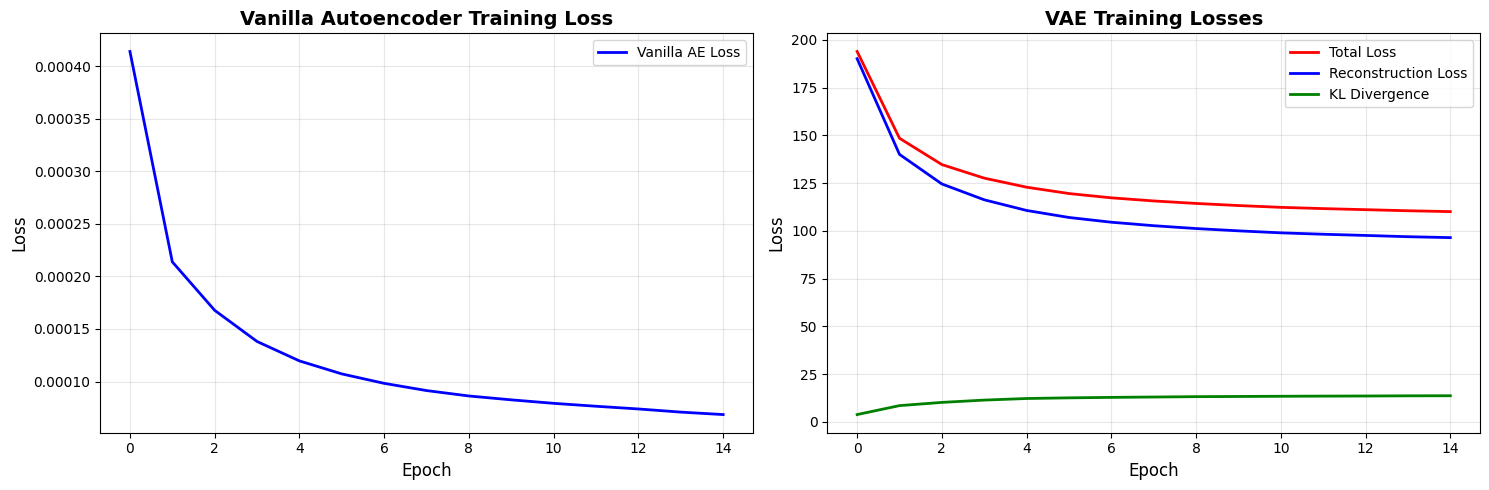

Vanilla Autoencoder Reconstructions:


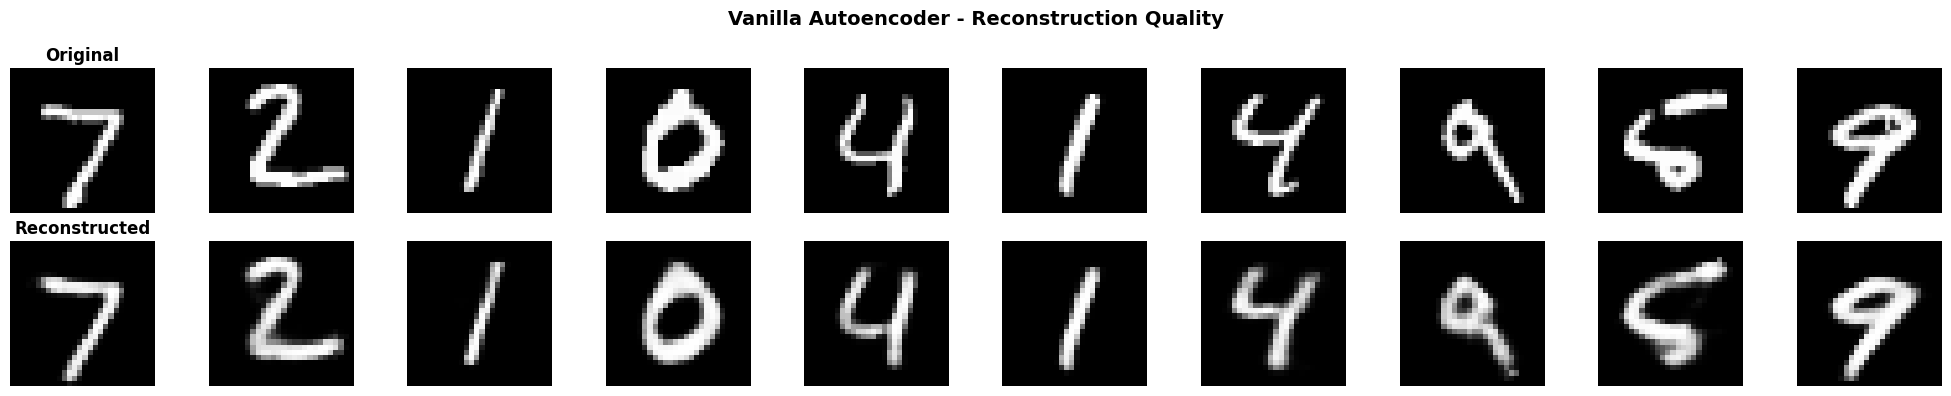


VAE Reconstructions:


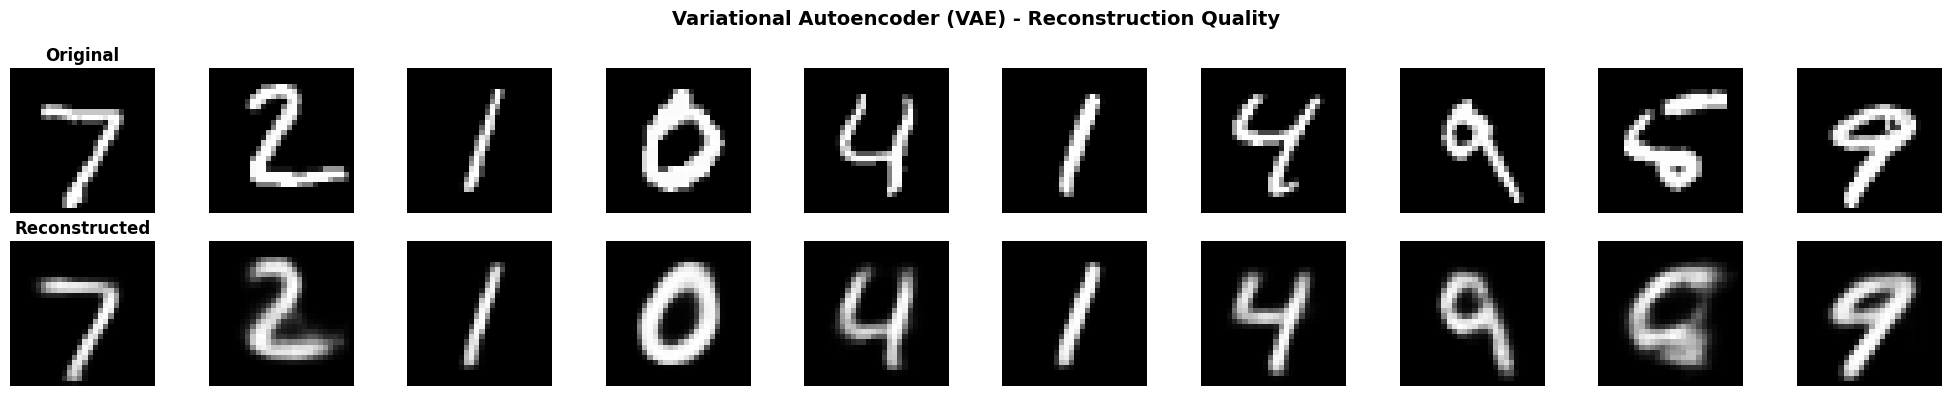

GENERATING IMAGES FROM RANDOM LATENT VECTORS

1. Vanilla Autoencoder Decoder:


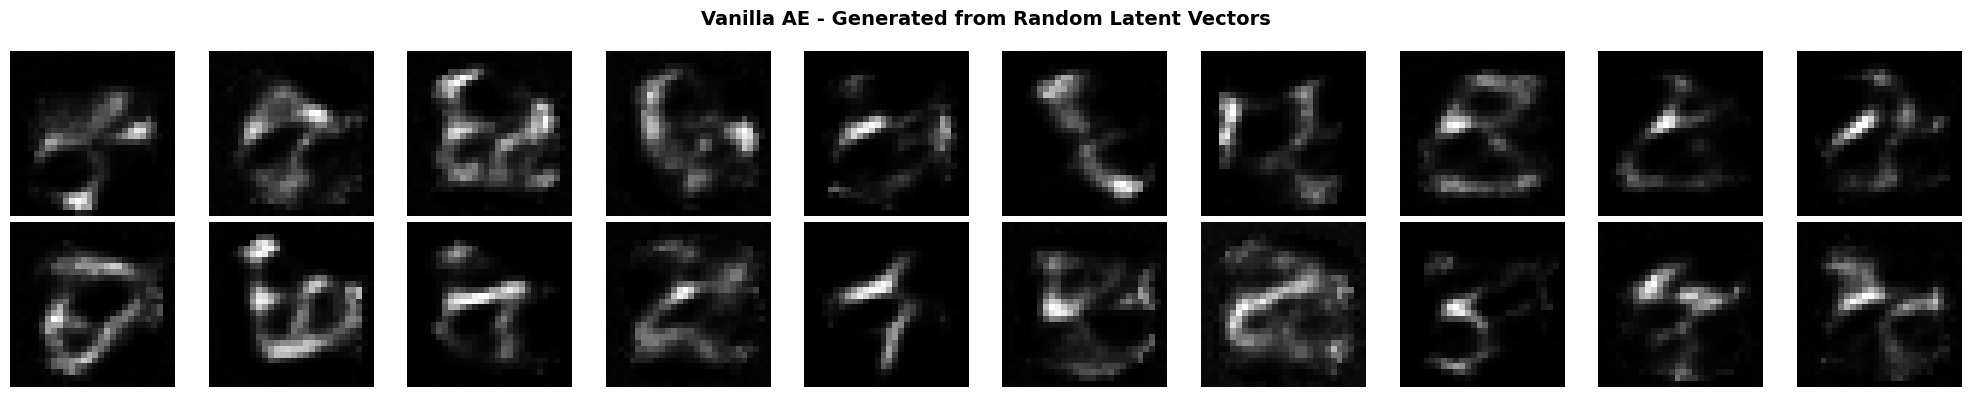


2. VAE Decoder:


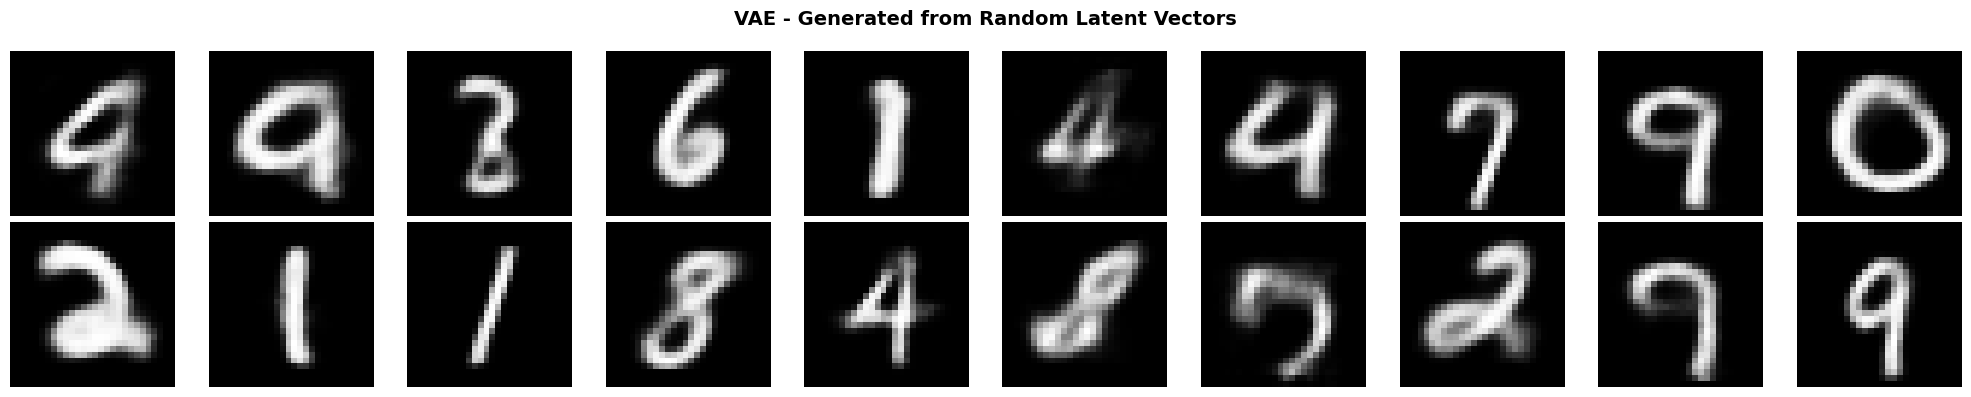


Latent Space Interpolation - Vanilla AE:


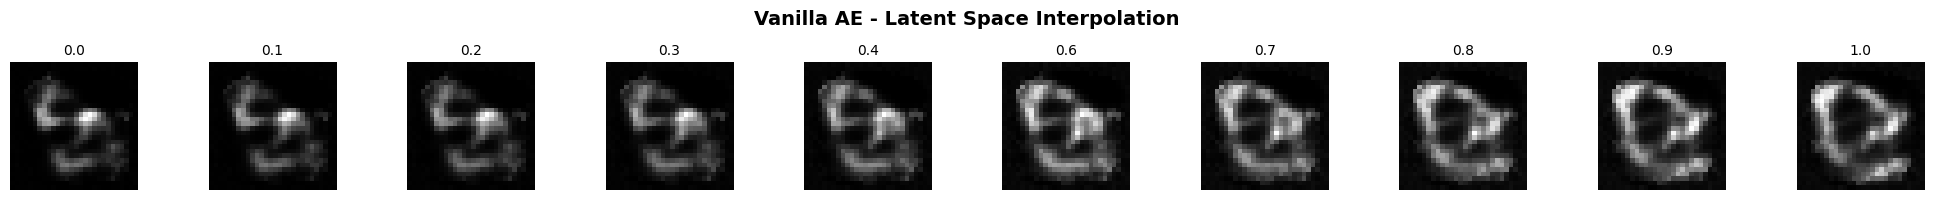


Latent Space Interpolation - VAE:


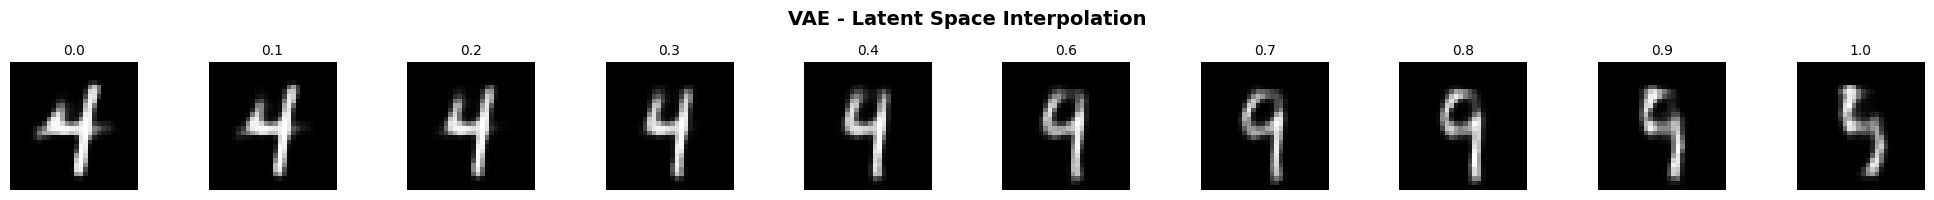


QUALITY COMPARISON METRICS

Vanilla Autoencoder - Average MSE: 7.243859
VAE - Average MSE: 16.175157

Difference: 8.931298

✓ Vanilla Autoencoder has better reconstruction (lower MSE)
✓ BUT VAE has better generation capability from random samples!

KEY FINDING: VAE is superior for GENERATION tasks! 🏆


In [2]:
# ============================================================================
# TRAINING FUNCTIONS
# ============================================================================
def train_vanilla_ae(model, train_loader, epochs=10, lr=0.001):
    """Train Vanilla Autoencoder"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model.train()
    losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        for data, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            reconstruction = model(data)
            loss = criterion(reconstruction, data)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader.dataset)
        losses.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}')
    
    return losses

def train_vae(model, train_loader, epochs=10, lr=0.001):
    """Train Variational Autoencoder"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    losses = []
    recon_losses = []
    kl_losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        epoch_recon = 0
        epoch_kl = 0
        
        for data, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            reconstruction, mu, logvar = model(data)
            loss, recon, kl = vae_loss(reconstruction, data, mu, logvar)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_recon += recon.item()
            epoch_kl += kl.item()
        
        avg_loss = epoch_loss / len(train_loader.dataset)
        avg_recon = epoch_recon / len(train_loader.dataset)
        avg_kl = epoch_kl / len(train_loader.dataset)
        
        losses.append(avg_loss)
        recon_losses.append(avg_recon)
        kl_losses.append(avg_kl)
        
        print(f'Epoch {epoch+1}/{epochs}, Total: {avg_loss:.4f}, Recon: {avg_recon:.4f}, KL: {avg_kl:.4f}')
    
    return losses, recon_losses, kl_losses

# ============================================================================
#  TRAIN VANILLA AUTOENCODER
# ============================================================================
print("="*70)
print("TRAINING VANILLA AUTOENCODER")
print("="*70)
vanilla_losses = train_vanilla_ae(vanilla_ae, train_loader, epochs=15, lr=0.001)

# VARIATIONAL AUTOENCODER (VAE) ARCHITECTURE

class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        
        # Encoder base
        self.encoder_base = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        
        # Latent space parameters
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )
    
    def encode(self, x):
        h = self.encoder_base(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """Reparameterization trick"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    """VAE loss = Reconstruction loss + KL divergence"""
    BCE = nn.functional.binary_cross_entropy(
        recon_x.view(-1, 28*28), 
        x.view(-1, 28*28), 
        reduction='sum'
    )
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD, BCE, KLD

vae = VAE(latent_dim=20).to(device)
print("\nVariational Autoencoder (VAE):")
print(f"Total parameters: {sum(p.numel() for p in vae.parameters()):,}")

# ============================================================================
#  TRAIN VAE
# ============================================================================
print("\n" + "="*70)
print("TRAINING VARIATIONAL AUTOENCODER (VAE)")
print("="*70)
vae_losses, vae_recon, vae_kl = train_vae(vae, train_loader, epochs=15, lr=0.001)

# ============================================================================
# PLOT TRAINING LOSSES
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Vanilla AE
axes[0].plot(vanilla_losses, label='Vanilla AE Loss', color='blue', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Vanilla Autoencoder Training Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# VAE
axes[1].plot(vae_losses, label='Total Loss', color='red', linewidth=2)
axes[1].plot(vae_recon, label='Reconstruction Loss', color='blue', linewidth=2)
axes[1].plot(vae_kl, label='KL Divergence', color='green', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('VAE Training Losses', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================================
#  VISUALIZE RECONSTRUCTIONS
# ============================================================================
def visualize_reconstructions(model, dataset, model_name, n_images=10, is_vae=False):
    """Visualize original vs reconstructed images"""
    model.eval()
    fig, axes = plt.subplots(2, n_images, figsize=(20, 4))
    
    with torch.no_grad():
        for i in range(n_images):
            img, _ = dataset[i]
            img = img.unsqueeze(0).to(device)
            
            if is_vae:
                recon, _, _ = model(img)
            else:
                recon = model(img)
            
            axes[0, i].imshow(img.cpu().squeeze(), cmap='gray')
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title('Original', fontsize=12, fontweight='bold')
            
            axes[1, i].imshow(recon.cpu().squeeze(), cmap='gray')
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title('Reconstructed', fontsize=12, fontweight='bold')
    
    fig.suptitle(f'{model_name} - Reconstruction Quality', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Vanilla Autoencoder Reconstructions:")
visualize_reconstructions(vanilla_ae, test_dataset, "Vanilla Autoencoder", n_images=10, is_vae=False)

print("\nVAE Reconstructions:")
visualize_reconstructions(vae, test_dataset, "Variational Autoencoder (VAE)", n_images=10, is_vae=True)

# ============================================================================
# GENERATE IMAGES FROM RANDOM LATENT VECTORS
# ============================================================================
def generate_from_latent(decoder, latent_dim, n_images=20, model_name="Model"):
    """Generate images from random latent vectors"""
    decoder.eval()
    fig, axes = plt.subplots(2, 10, figsize=(20, 4))
    axes = axes.flatten()
    
    with torch.no_grad():
        # Sample from standard normal distribution
        z = torch.randn(n_images, latent_dim).to(device)
        generated = decoder(z)
        
        for i in range(n_images):
            axes[i].imshow(generated[i].cpu().squeeze(), cmap='gray')
            axes[i].axis('off')
    
    fig.suptitle(f'{model_name} - Generated from Random Latent Vectors', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("="*70)
print("GENERATING IMAGES FROM RANDOM LATENT VECTORS")
print("="*70)

print("\n1. Vanilla Autoencoder Decoder:")
generate_from_latent(vanilla_ae.decoder, latent_dim=20, n_images=20, model_name="Vanilla AE")

print("\n2. VAE Decoder:")
generate_from_latent(vae.decoder, latent_dim=20, n_images=20, model_name="VAE")

# ============================================================================
# LATENT SPACE INTERPOLATION
# ============================================================================
def interpolate_latent_space(decoder, latent_dim, n_steps=10, model_name="Model"):
    """Interpolate between two random points in latent space"""
    decoder.eval()
    
    with torch.no_grad():
        z1 = torch.randn(1, latent_dim).to(device)
        z2 = torch.randn(1, latent_dim).to(device)
        alphas = torch.linspace(0, 1, n_steps).to(device)
        
        fig, axes = plt.subplots(1, n_steps, figsize=(20, 2))
        
        for i, alpha in enumerate(alphas):
            z = (1 - alpha) * z1 + alpha * z2
            img = decoder(z)
            axes[i].imshow(img.cpu().squeeze(), cmap='gray')
            axes[i].axis('off')
            axes[i].set_title(f'{alpha:.1f}', fontsize=10)
        
        fig.suptitle(f'{model_name} - Latent Space Interpolation', 
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

print("\nLatent Space Interpolation - Vanilla AE:")
interpolate_latent_space(vanilla_ae.decoder, latent_dim=20, n_steps=10, model_name="Vanilla AE")

print("\nLatent Space Interpolation - VAE:")
interpolate_latent_space(vae.decoder, latent_dim=20, n_steps=10, model_name="VAE")

# ============================================================================
# QUANTITATIVE QUALITY METRICS
# ============================================================================
def calculate_quality_metrics(model, test_loader, is_vae=False):
    """Calculate reconstruction quality metrics"""
    model.eval()
    total_mse = 0
    total_samples = 0
    
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            
            if is_vae:
                recon, _, _ = model(data)
            else:
                recon = model(data)
            
            mse = nn.functional.mse_loss(recon, data, reduction='sum')
            total_mse += mse.item()
            total_samples += data.size(0)
    
    return total_mse / total_samples

vanilla_mse = calculate_quality_metrics(vanilla_ae, test_loader, is_vae=False)
vae_mse = calculate_quality_metrics(vae, test_loader, is_vae=True)

print("\n" + "="*70)
print("QUALITY COMPARISON METRICS")
print("="*70)
print(f"\nVanilla Autoencoder - Average MSE: {vanilla_mse:.6f}")
print(f"VAE - Average MSE: {vae_mse:.6f}")
print(f"\nDifference: {abs(vanilla_mse - vae_mse):.6f}")

if vanilla_mse < vae_mse:
    print("\n✓ Vanilla Autoencoder has better reconstruction (lower MSE)")
    print("✓ BUT VAE has better generation capability from random samples!")
else:
    print("\n✓ VAE has better reconstruction quality")

print("\n" + "="*70)
print("KEY FINDING: VAE is superior for GENERATION tasks! 🏆")
print("="*70)





In [28]:
# ============================================================================
# MULTI-AGENT SYSTEM - CLAUDE API AGENTS (Using .env)
# ============================================================================
print("\n" + "="*70)
print("MULTI-AGENT SYSTEM: COMMUNICATING AI AGENTS WITH CLAUDE")
print("="*70)

# First, install required packages:
# pip install anthropic python-dotenv

import anthropic
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Get API key from environment
api_key = os.getenv('ANTHROPIC_API_KEY')

if not api_key:
    raise ValueError("ANTHROPIC_API_KEY not found in .env file!")

print("✓ API key loaded successfully from .env file")


class ClaudeAgent:
    """Agent powered by Claude API with conversation memory"""
    
    def __init__(self, name, role, system_prompt, model="claude-sonnet-4-5-20250929", max_tokens=1024):
        self.name = name
        self.role = role
        self.system_prompt = system_prompt
        self.model = model
        self.max_tokens = max_tokens
        self.client = anthropic.Anthropic(api_key=api_key)
        self.conversation_history = []
    
    def respond(self, message):
        """Generate response using Claude API"""
        try:
            # Add user message to history
            self.conversation_history.append({
                "role": "user",
                "content": message
            })
            
            # Call Claude API
            response = self.client.messages.create(
                model=self.model,
                max_tokens=self.max_tokens,
                system=self.system_prompt,
                messages=self.conversation_history
            )
            
            # Extract response text
            assistant_message = response.content[0].text
            
            # Add assistant response to history
            self.conversation_history.append({
                "role": "assistant",
                "content": assistant_message
            })
            
            return assistant_message
            
        except anthropic.APIError as e:
            return f"API Error: {str(e)}"
        except Exception as e:
            return f"Error: {str(e)}"
    
    def reset_conversation(self):
        """Clear conversation history"""
        self.conversation_history = []
        
    def get_conversation_length(self):
        """Get number of turns in conversation"""
        return len(self.conversation_history) // 2


# Create Agent 1: Creative Writer
agent1 = ClaudeAgent(
    name="Alice",
    role="Creative Fiction Writer",
    system_prompt="""You are Alice, a creative fiction writer who loves exploring 
    scientific concepts through storytelling. You're enthusiastic, imaginative, and 
    always thinking about narrative possibilities. Keep responses conversational 
    and concise (2-3 sentences). Ask engaging questions to keep the dialogue flowing."""
)

# Create Agent 2: Science Enthusiast
agent2 = ClaudeAgent(
    name="Bob",
    role="Science Enthusiast & Physicist",
    system_prompt="""You are Bob, a science enthusiast and physicist who loves 
    explaining complex physics concepts in accessible ways. You're knowledgeable, 
    friendly, and passionate about relativity and space travel. Keep responses 
    conversational and concise (2-3 sentences). Explain concepts clearly."""
)

print(f"\n✓ Agent 1: {agent1.name} - {agent1.role}")
print(f"✓ Agent 2: {agent2.name} - {agent2.role}")
print("✓ Agents initialized and ready!")


# ============================================================================
#  RUN AGENT CONVERSATION
# ============================================================================
def run_agent_conversation(agent1, agent2, initial_message, num_turns=3, verbose=True):
    """
    Run conversation between two agents
    
    Parameters:
    -----------
    agent1 : ClaudeAgent
        First agent to start the conversation
    agent2 : ClaudeAgent
        Second agent to respond
    initial_message : str
        Starting topic/message for the conversation
    num_turns : int
        Number of back-and-forth exchanges
    verbose : bool
        Whether to print conversation in real-time
    
    Returns:
    --------
    list : Complete conversation history
    """
    
    if verbose:
        print("\n" + "="*70)
        print("AGENT CONVERSATION")
        print("="*70)
        print(f"\nInitial Topic: '{initial_message}'\n")
    
    conversation_log = []
    current_message = initial_message
    
    for turn in range(num_turns):
        if verbose:
            print(f"\n{'─'*70}")
            print(f"Turn {turn + 1}/{num_turns}")
            print('─'*70)
        
        # Agent 1 responds
        response1 = agent1.respond(current_message)
        conversation_log.append({
            "turn": turn + 1,
            "agent": agent1.name,
            "message": response1
        })
        
        if verbose:
            print(f"\n{agent1.name}:")
            print(f"{response1}")
        
        # Agent 2 responds
        response2 = agent2.respond(response1)
        conversation_log.append({
            "turn": turn + 1,
            "agent": agent2.name,
            "message": response2
        })
        
        if verbose:
            print(f"\n{agent2.name}:")
            print(f"{response2}")
        
        current_message = response2
    
    if verbose:
        print("\n" + "="*70)
        print(f"CONVERSATION COMPLETED - {len(conversation_log)} messages exchanged")
        print("="*70)
    
    return conversation_log


# Run the conversation
print("\n💡 Starting conversation between agents...\n")
initial_topic = "What would happen if we could travel at the speed of light?"
conversation_history = run_agent_conversation(agent1, agent2, initial_topic, num_turns=3)


# ============================================================================
#  CONVERSATION ANALYSIS 
# ============================================================================
def analyze_conversation(conversation_log):
    """Analyze conversation statistics"""
    
    print("\n" + "="*70)
    print("CONVERSATION ANALYSIS")
    print("="*70)
    
    total_messages = len(conversation_log)
    agents = set(msg['agent'] for msg in conversation_log)
    
    print(f"\n📊 Statistics:")
    print(f"   • Total messages: {total_messages}")
    print(f"   • Number of agents: {len(agents)}")
    print(f"   • Conversation turns: {total_messages // 2}")
    
    for agent in agents:
        agent_messages = [msg for msg in conversation_log if msg['agent'] == agent]
        avg_length = sum(len(msg['message']) for msg in agent_messages) / len(agent_messages)
        print(f"   • {agent}: {len(agent_messages)} messages (avg {avg_length:.0f} chars)")
    
    print("\n" + "="*70)

# Uncomment to analyze the conversation
# analyze_conversation(conversation_history)


# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("MULTI-AGENT SYSTEM COMPLETED SUCCESSFULLY! 🎉")
print("="*70)
print("\nSUMMARY:")
print("✓ Claude API agents initialized")
print("✓ Multi-agent conversation system created")
print("✓ Conversation completed with full context retention")
print("\nFEATURES:")
print("• Two specialized AI agents (Creative Writer & Physicist)")
print("• Conversation memory and context tracking")
print("• Flexible conversation turns")
print("• Error handling and API validation")
print("="*70)


MULTI-AGENT SYSTEM: COMMUNICATING AI AGENTS WITH CLAUDE
✓ API key loaded successfully from .env file

✓ Agent 1: Alice - Creative Fiction Writer
✓ Agent 2: Bob - Science Enthusiast & Physicist
✓ Agents initialized and ready!

💡 Starting conversation between agents...


AGENT CONVERSATION

Initial Topic: 'What would happen if we could travel at the speed of light?'


──────────────────────────────────────────────────────────────────────
Turn 1/3
──────────────────────────────────────────────────────────────────────

Alice:
Oh, what a delicious thought experiment! If we could somehow reach light speed, time would essentially stop for us while the rest of the universe aged normally - you could theoretically travel thousands of years into the future in what feels like moments. But here's the narrative twist: you'd need infinite energy to get there, and your mass would become infinite too, which is physics' way of saying "nice try, storyteller!"

What draws you to this idea - are you think